Analiza wpływu hiperparametrów

#Zadanie 1
Wpływ Learning Rate

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [ ]:
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0 #Zmiana kształtu i normalizacja danych treningowych
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0 #Zmiana kształtu i normalizacja danych testowych


##Inicjalizacja modelu MLP

In [ ]:
class MLPmodel(keras.Model):
  def __init__(self, n_features, n_ukryta1=64, n_ukryta2=32, n_classes=10):
    super(MLPmodel, self).__init__() #Wywołanie konstruktora
    self.warstwa1 = layers.Dense(n_ukryta1, activation='relu')
    self.warstwa2 = layers.Dense(n_ukryta2, activation='relu')
    #klasyfikacja: 10 wyjść do softmax
    self.wyjscie = layers.Dense(n_classes, activation='softmax') #Warstwa wyjściowa

  def call(self, x): #Przepływ danych przez model
    x = self.warstwa1(x)
    x = self.warstwa2(x)
    return self.wyjscie(x)

##Wpływ zmiany wartości dla learning rate podczas uczenia

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1] #Lista współczynników uczenia do przetestowania
histories_lr={} #Słownik do przechowywania historii treningu dla każdego współczynnika uczenia

##Proces uczenia/trenowania modelu MLP

In [ ]:
for lr in learning_rates:
  model = MLPmodel(n_features=784)

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss=keras.losses.SparseCategoricalCrossentropy(),
      metrics=['accuracy']
  )

  history = model.fit(
      x_train, y_train,
      epochs=20, batch_size=64,
      validation_split=0.2,
      verbose=0
  )

  histories_lr[lr] = history

  print(f"LR={lr} dla val_accuracy: {max(history.history['val_accuracy']):.4f}")

LR=0.0001 dla val_accuracy: 0.9574
LR=0.001 dla val_accuracy: 0.9733
LR=0.01 dla val_accuracy: 0.9661
LR=0.1 dla val_accuracy: 0.1081


##Wizualizacja

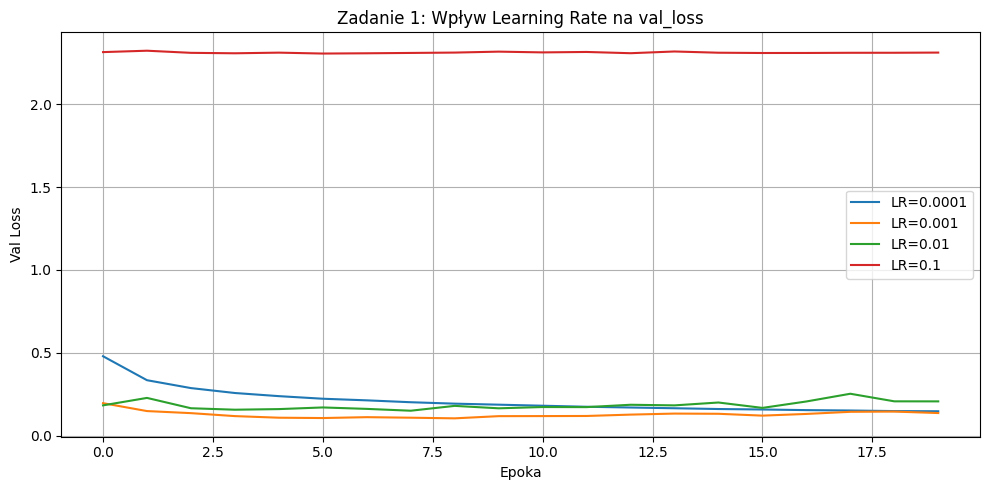

In [ ]:
plt.figure(figsize=(10,5))

for lr, h in histories_lr.items():
  plt.plot(h.epoch, h.history['val_loss'], label=f'LR={lr}')
plt.title('Zadanie 1: Wpływ Learning Rate na val_loss')
plt.xlabel('Epoka'); plt.ylabel('Val Loss')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('zad1_lr.png'); plt.show()

#Zadanie 2
Wpływ batch_size

In [ ]:
batch_sizes = [16, 64, 256, 1024]
histories_bs={}

###Proces uczenia/trenowania modelu

In [ ]:
for bs in batch_sizes:
  model = MLPmodel(n_features=784)
  model.compile(
      optimizer='adam',
      loss=keras.losses.SparseCategoricalCrossentropy(),
      metrics=['accuracy']
      )

  history = model.fit(
      x_train, y_train,
      epochs=20, batch_size=bs,
      validation_split=0.2,
      verbose=0
  )

  histories_bs[bs] = history

  print(f"LR={bs:5} dla val_accuracy: {max(history.history['val_accuracy']):.4f}")

LR=   16 dla val_accuracy: 0.9744
LR=   64 dla val_accuracy: 0.9726
LR=  256 dla val_accuracy: 0.9721
LR= 1024 dla val_accuracy: 0.9667


###Wizualizacja

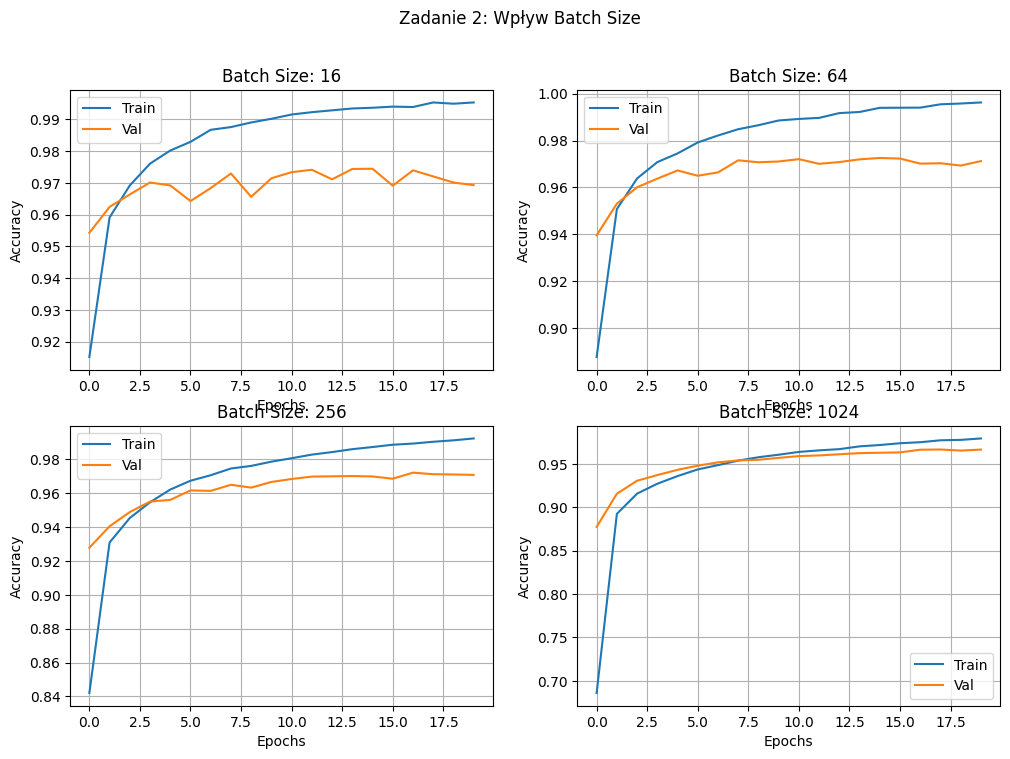

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, bs in zip(axes.flatten(), batch_sizes):
  ax.plot(histories_bs[bs].history['accuracy'], label='Train') #Rysowanie dokładności treningowej
  ax.plot(histories_bs[bs].history['val_accuracy'], label='Val') #Rysowanie dokładności walidacyjnej
  ax.set_title(f'Batch Size: {bs}')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Accuracy')
  ax.legend(); ax.grid(True)
plt.suptitle('Zadanie 2: Wpływ Batch Size')
plt.savefig('zad2_bs.png'); plt.show()

#Zadanie 3
Porównanie optymalizatory uczenia

In [ ]:
optimizers_cfg = { #Słownik definiujący różne konfiguracje optymalizatorów
    'SGD': {'optimizer': keras.optimizers.SGD(learning_rate=0.01)},
    'RMSprop': {'optimizer': keras.optimizers.RMSprop(learning_rate=0.01)},
    'Adam': {'optimizer': keras.optimizers.Adam(learning_rate=0.01)},
}

##Proces uczenia/trenowania modelu

In [ ]:
histories_opt = {}

for name, opt in optimizers_cfg.items():
  model = MLPmodel(n_features=784)
  model.compile(optimizer=opt['optimizer'], loss=keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

  history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=0)
  histories_opt[name] = history

  print(f"{name} dla val_accuracy: {max(history.history['val_accuracy']):.4f}")

SGD dla val_accuracy: 0.9538
RMSprop dla val_accuracy: 0.9646
Adam dla val_accuracy: 0.9677


###Wizualizacja

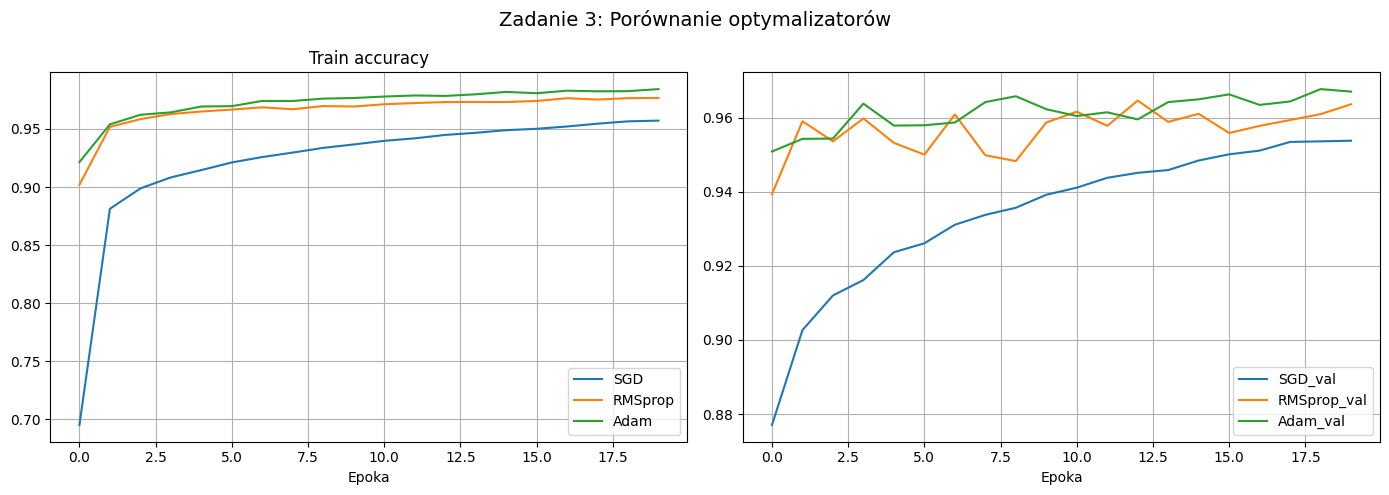

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

for name, h in histories_opt.items(): #Pętla przez historie treningu
  ax1.plot(h.history['accuracy'], label=name)
  ax2.plot(h.history['val_accuracy'], label=f'{name}_val')
ax1.set_title('Train accuracy')

for ax in (ax1, ax2): #Pętla przez oba subploty
  ax.set_xlabel('Epoka'); ax.legend(); ax.grid(True)

plt.suptitle('Zadanie 3: Porównanie optymalizatorów', fontsize=14)
plt.tight_layout(); plt.savefig('zad3_opt.png'); plt.show()

#Zadanie 4
Wypłw ilości warstw ukrytych

Inicjalizacja modelu MLP ze zmienną ilością wartsw ukrytych

In [ ]:
class MLPmodelDowolny(keras.Model):

  def __init__(self, n_features, ukryta_layers : list, n_classes=10):
    super(MLPmodelDowolny, self).__init__()
    self.ukryta = [layers.Dense(n, activation='relu') for n in ukryta_layers] #Lista warstw ukrytych
    self.wyjscie = layers.Dense(n_classes, activation='softmax')

  def call(self, x):
    for warstwa in self.ukryta:
      x = warstwa(x)
    return self.wyjscie(x)

Wpływ zmiany liczby warstw ukrytych

In [ ]:
NEURON = 64 #Zmień liczbę neuronów, aby przetestować różne rozmiary neuronów w warstwach

architectures = {
    "1 warstwa": [NEURON],
    "2 warstwy": [NEURON, NEURON],
    "3 warstwy": [NEURON, NEURON, NEURON],
    "4 warstwy": [NEURON, NEURON, NEURON, NEURON]
}

results_arch = {}

Proces uczenia/trenowania modelu

In [ ]:
for name, cfg in architectures.items():
  model = MLPmodelDowolny(n_features=784, ukryta_layers=cfg)

  model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
  history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=0)
  _, acc = model.evaluate(x_test, y_test, verbose=1)
  results_arch[name] = {
      'history': history,
      'accuracy': acc
  }

  print(f"[NEURON={NEURON}] {name:12} dla val_accuracy: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9741 - loss: 0.0942
[NEURON=64] 1 warstwa    dla val_accuracy: 0.9741
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.1209
[NEURON=64] 2 warstwy    dla val_accuracy: 0.9740
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9760 - loss: 0.1254
[NEURON=64] 3 warstwy    dla val_accuracy: 0.9760
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9713 - loss: 0.1406
[NEURON=64] 4 warstwy    dla val_accuracy: 0.9713


Wizualizacja

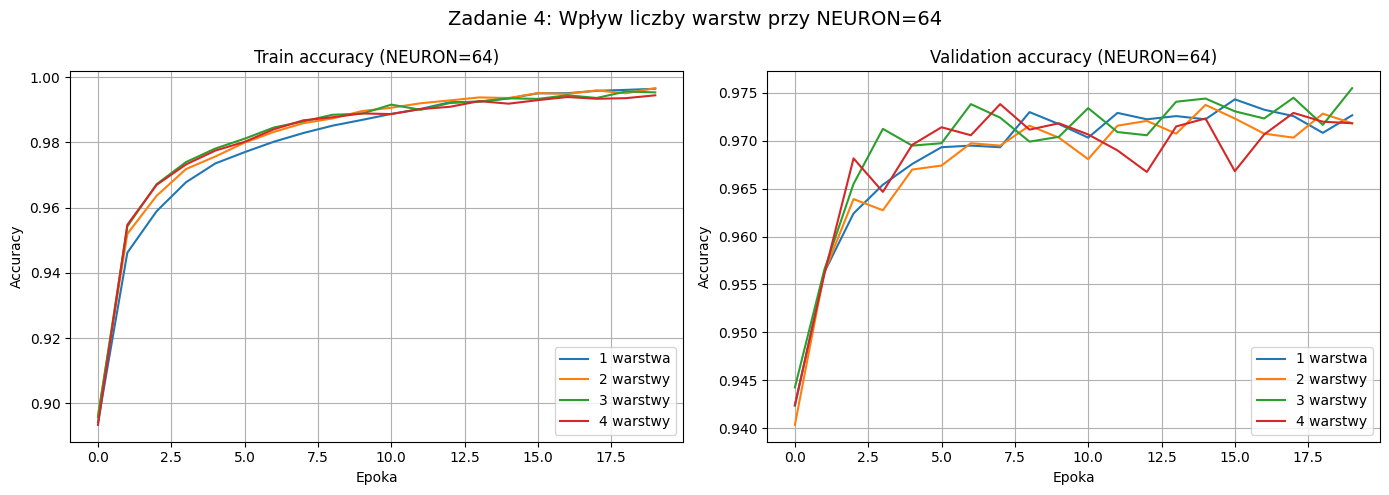

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

for name, res in results_arch.items():
  ax1.plot(res['history'].history['accuracy'], label=name)
  ax2.plot(res['history'].history['val_accuracy'], label=name)

ax1.set_title(f'Train accuracy (NEURON={NEURON})')
ax2.set_title(f'Validation accuracy (NEURON={NEURON})')

for ax in (ax1, ax2):
  ax.set_xlabel('Epoka');
  ax.set_ylabel('Accuracy');
  ax.legend(); ax.grid(True)

plt.suptitle(f'Zadanie 4: Wpływ liczby warstw przy NEURON={NEURON}', fontsize=14)
plt.tight_layout()
plt.savefig('zad4_architektura_units.png')
plt.show()

#Zadanie 5
Wszystko w jednym na podstawie Fashion-MNIST (reshape + normalizacja):

1.   Wpływ learning rate
2.   Porówannie min 2 różnych architektur sieci
3.   Zbadanie wpływ batch size (min 2 wartości)
4.   Porównanie optymalizatorów (min 2)

